# Introduction
## Literature

Lecture slides: <br>
*Microscopy and Diffractometry*

Books: <br>
*Transmission electron microscopy* by Carter and Williams
<br> 
*Transmission electron microscopy* by Fultz and Howe
<br>
*International Tables for Crystallography* by IUCR

Articles: <br>
*Dinnebier R, Scardi P. X-ray powder diffraction in education. Part I. Bragg peak profiles. Applied Crystallography. 2021;54(6):1811–31.*
<br>
*Dinnebier R, Scardi P. X-ray powder diffraction in education. Part II. Intensity of a powder pattern. Applied Crystallography. 2023;56(3):834–53.*

Documentations: <br>
*Bergmann J. Manual, Rietveld Analysis Program BGMN*
<br>
*Rodríguez-Carvajal J. An introduction to the program FullProf 2000*
<br>
*Altomare A, Cuocci C et al. EXPO2014 - Crystal structures solution by powder diffraction data*
<br>
*SasView Documentation*
<br>
*SHELX Manual*

## Examination

1 hour, multiple choice

# Radiation properties
## Wavelength dispersion

Relativistic energy $E$, momentum $p$, speed of light in vacuum $c$, and mass $m$:
WavelengthE^2&=p^2c^2+m^2c^4
\end{align}

Electromagnetic waves, $m=0$:
\begin{align}
p&=h/\lambda\\
E&=hc/\lambda=h\nu=\hbar\omega\\
h&=2\pi\hbar=6.626\cdot10^{-34}\text{~J}\cdot\text{s}\\
hc&=1.986\cdot10^{-25}\text{~J}\cdot\text{m}
\end{align}

Masses of electrons \& neutrons:
\begin{align}
m_\text{e}&=9.109\cdot10^{-31}\text{~kg}\\
m_\text{n}&=1.674\cdot10^{-27}\text{~kg}
\end{align}

Particle waves, $m\neq0$ with velocity $v$ and Lorentz factor $\gamma$:
\begin{align}
p&=h/\lambda=\gamma mv\\
E&=\gamma mc^2=mc^2+(\gamma-1)mc^2\\
\gamma&=\left(1-(v/c)^2\right)^{-1/2}\\
E_\text{kin}&=\frac{mv^2}{2}=\frac{E(1+\gamma)}{2\gamma^2}=\frac{p^2}{2m}
\end{align}

Energy of electrons with charge $e$ under an accelerating voltage $U$, unit of energy electronvolt eV (1~C=1~J/V):
\begin{align}
E&=eU\\
e&=1.602\cdot10^{-19}\text{~C}\\
1\text{~eV}&=1.602\cdot10^{-19}\text{~J}
\end{align}

**Tasks**

Calculate the following wavelengths:
- Electromagnetic up to 1 GeV
- Electron up to 1 GeV


$$\left[ \frac{h \sqrt{\frac{c^{4} m^{2}}{E^{2}}}}{c m \sqrt{1.0 - \frac{c^{4} m^{2}}{E^{2}}}}\right]$$

In [1]:
from sympy import *

E,h,lamb,gamma,m,v,c,p=symbols('E h lamb gamma m v c p')
gamma=(1-(v/c)**2)**(-1/2)
v=solve(gamma*m*c**2-E,v)[1]
print(v)
gamma=(1-(v/c)**2)**(-1/2)
lamb=solve(gamma*m*v-h/lamb,lamb)
print(lamb)
print(latex(lamb))

c*sqrt(1.0 - c**4*m**2/E**2)
[h*sqrt(c**4*m**2/E**2)/(c*m*sqrt(1.0 - c**4*m**2/E**2))]
\left[ \frac{h \sqrt{\frac{c^{4} m^{2}}{E^{2}}}}{c m \sqrt{1.0 - \frac{c^{4} m^{2}}{E^{2}}}}\right]


## Momentum transfer + values

Wave vector $k$, momentum transfer = scattering vector $q$, scattering angle $2\theta$, and interference condition with structural dimension $r$ and $n\in \mathbb{N}$:

\begin{align}
k&=2\pi/\lambda\\
q&=2k\sin\theta\\
q&=2\pi n/r
\end{align}

**Tasks**
- Calculate the scattering vectors attainable with copper Kalpha radiation
- Calculate the structural dimensions determinable with copper Kalpha radiation

# Single scatterer properties
## Scattering cross sections
### Elastic

Autocorrelation & empirical formulae with density $\rho$.

\begin{align}
f(q)&=4\pi\int\limits_0^\infty r^2\rho(r)\frac{\sin(qr)}{qr}\mathrm{d}r\\
f(q)&=\sum _{i=1}^{4}a_{i}\exp \left(-b_{i}\left({\frac {q}{4\pi }}\right)^{2}\right)+c
\end{align}

**Tasks**
- Calculate the atomic scattering factors for $0<q/\mathrm{\mathring{A}}^{-1}<10$ for H, C, U

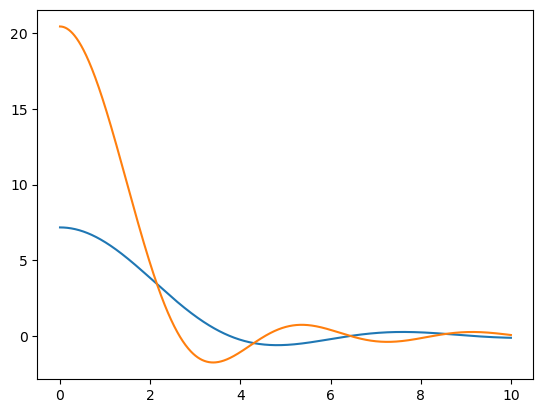

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def autocorr(q,rhor):
    f=np.zeros(q.shape)
    for iq,dq in enumerate(q):
        f[iq]=4*np.pi*np.trapz(r**2*rhor*np.sin(dq*r)/(dq*r),x=r)
    return f

r=np.linspace(1e-9,10,num=1000)
q=np.linspace(1e-9,10,num=1000)

rhoH=np.zeros(r.shape);rhoH[r<1.2]=1
rhoC=np.zeros(r.shape);rhoC[r<1.7]=1
#rhoU=np.zeros(r.shape);rhoU[r<13.9]=1
# a0=1.2
# rhoH=1/(np.pi*a0**3)*np.exp(-2*r/a0)
# a0=1.7
# rhoC=6/(np.pi*a0**3)*np.exp(-2*r/a0)

plt.plot(q,autocorr(q,rhoH))
plt.plot(q,autocorr(q,rhoC))
#plt.plot(q,autocorr(q,rhoU))

plt.show()

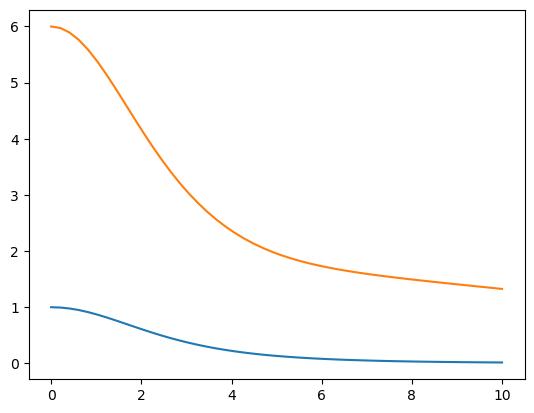

In [14]:

import numpy as np
import matplotlib.pyplot as plt

def f(q,coeffs):
    f=np.full(q.shape,coeffs[-1])
    for i in range(len(coeffs)//2):
        f+=coeffs[2*i]*np.exp(-coeffs[2*i+1]*(q/(4*np.pi))**2)
    return f

q=np.linspace(0,10)

CoeffsH=[0.489918,20.6593,0.262003,7.74039,0.196767,49.5519,0.049879,2.20159,0.001305]
CoeffsC=[2.31,20.8439,1.02,10.2075,1.5886,0.5687,0.865,51.6512,0.2156]
CoeffsU=[36.0228,0.5293,23.4128,3.3253,14.9491,16.0927,4.188,100.613,13.3966]

plt.plot(q,f(q,CoeffsH))
plt.plot(q,f(q,CoeffsC))
#plt.plot(q,f(q,CoeffsU))

plt.show()

/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


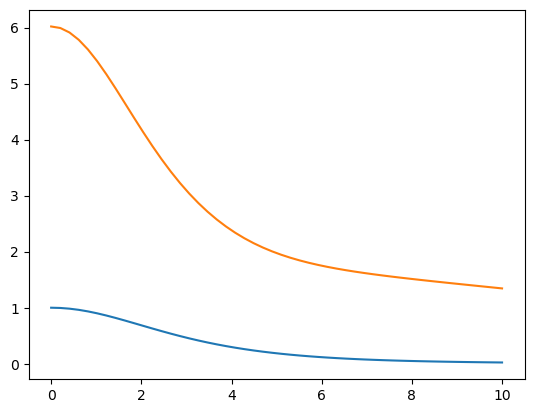

In [15]:
import numpy as np
import xrayutilities as xu
import matplotlib.pyplot as plt

q=np.linspace(0,10)

H=xu.materials.atom.Atom('H',1)
C=xu.materials.atom.Atom('C',1)
U=xu.materials.atom.Atom('U',1)

plt.plot(q,H.f(q))
plt.plot(q,C.f(q))
#plt.plot(q,U.f(q))
#xu.utilities_noconf.energy('CuKa1')

plt.show()

### Inelastic

\begin{align}
{\frac {d\sigma }{d\Omega }}={\frac {1}{2}}r_{e}^{2}\left({\frac {\lambda }{\lambda '}}\right)^{2}\left[{\frac {\lambda }{\lambda '}}+{\frac {\lambda '}{\lambda }}-\sin ^{2}(\theta )\right]
\end{align}

**Tasks**
- Calculate the inelastic cross-section per electron for a scattering event with a given relative energy loss

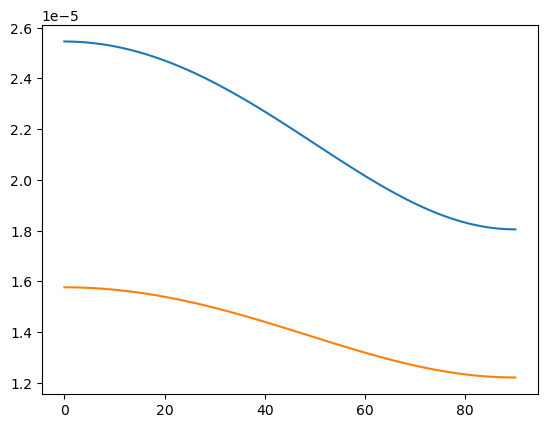

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def DCKN(ratio,theta):
    return re**2*ratio**2/2*(ratio+1/ratio-np.sin(theta)**2)

re=2.82e-15*1e10
theta=np.linspace(0,90)

plt.plot(theta,DCKN(0.9,np.radians(theta))**0.5)
plt.plot(theta,DCKN(0.5,np.radians(theta))**0.5)

plt.show()

## Transmissions

Lambert-Beer law with transmittance $T$, transmitted and impinging intensities $I$ and $I_0$, attenuation coefficient $\mu=\sum\limits_i\mu_i$.

\begin{align}
T=I/I_0=\exp(-\mu d)
\end{align}

With $T$

https://physics.nist.gov/PhysRefData/Xcom/html/xcom1.html
<br>
https://web-docs.gsi.de/~stoe_exp/web_programs/x_ray_absorption/index.php

**Tasks**

-Calculate the thicknesses of mineral oil, graphite and metallic uranium at which half the intensity of an incoming X-ray beam is transmitted

0.12244897959183673


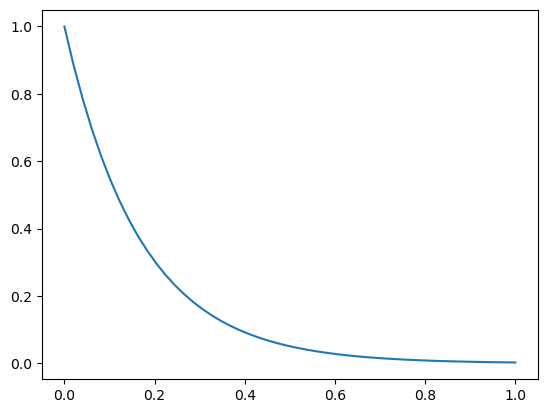

In [2]:
import numpy as np
import matplotlib.pyplot as plt

d=np.linspace(0,1)    #cm

rho=1.5               #g/cm^3
coeff=3.975           #cm^2/g

mu=rho*coeff

I=np.exp(-mu*d)
print(d[np.where(I<0.5)][0])

plt.plot(d,I)

plt.show()

# Interference

General case

\begin{align}
I(q)=\sum\limits_j^N\sum\limits_{k}^Nf_j(q)f_k(q)\exp(i\mathbf{qr}_{jk})
\end{align}

Amorphous case, Deybe equation
\begin{align}
I(q)&=\sum\limits_j^N\sum\limits_{k}^Nf_j(q)f_k(q)\frac{\sin(qr_{jk})}{qr_{jk}}\\
&=\sum_{j}^Nf_j^2(q)+\sum\limits_j^N\sum\limits_{k\neq j}^Nf_j(q)f_k(q)\frac{\sin(qr_{jk})}{qr_{jk}}\\
S(q)&=I(q)/\sum_{j}^Nf_j^2(q)
\end{align}

Crystalline case, structure factors
\begin{align}
I(q)&=F_{hkl}(q)\cdot F^*_{hkl}(q)=|F_{hkl}(q)|^2\\
F_{hkl}(q)&=\sum\limits_{j}^Nf_j(q)\exp{\left(i2\pi(hu_j+kv_j+lw_j)\right)}
\end{align}

**Tasks**

-Calculate $I(q)$ for BCC iron via the Debye equation and the structure factor

Debye: 172.1991250514984
Powder diffraction object
-------------------------
Powder-Fe (a: 2.8665, at0_Fe_2a_occupation: 1, at0_Fe_2a_biso: 0, volume: 1, )
Lattice:
229 cubic Im-3m: a = 2.8665, b = 2.8665 c= 2.8665
alpha = 90.000, beta = 90.000, gamma = 90.000
Lattice base:
0: Fe (26) 2a  occ=1.000 b=0.000
Reflection conditions:
 general: hkl: h+k+l=2n, 0kl: k+l=2n, hhl: l=2n, h00: h=2n
2a      : None

Reflections:
------------
      h k l     |    tth    |    |Q|    |Int     |   Int (%)
   ---------------------------------------------------------------
      (1, 1, 0)    44.6714      3.100       152.36      100.00
      (2, 0, 0)    65.0201      4.384        22.09       14.50
     (1, 1, -2)    82.3309      5.369        41.99       27.56
      (2, 2, 0)    98.9399      6.200        14.35        9.42
      (3, 1, 0)   116.3753      6.932        27.07       17.77
      (2, 2, 2)   137.1468      7.593        11.81        7.75

XU 0.3352198600769043


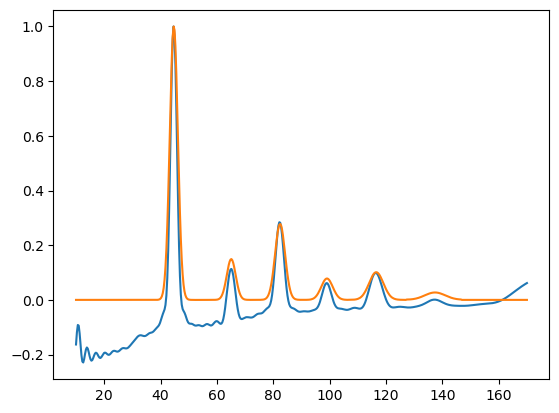

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import xrayutilities as xu
import time

tt=np.linspace(10,170,num=500)
q=4*np.pi*np.sin(np.radians(tt/2))/1.5406
iron=xu.materials.atom.Atom('Fe',1)
f=np.real(iron.f(q,en=xu.utilities_noconf.energy('CuKa1')))

bt=time.time()
x_p=np.arange(10)
coords=np.vstack(np.meshgrid(x_p,x_p,x_p)).reshape(3,-1).T
coords=np.append(coords,coords+0.5,axis=0)
coords*=2.8665

I=np.zeros(len(q))
for c0 in coords:
    for c1 in coords:
        r=np.linalg.norm(c0-c1)
        if r>0:
            I+=f**2*np.sin(q*r)/(q*r)
plt.plot(tt,I/max(I))
print('Debye:',time.time()-bt)

bt=time.time()
mat=xu.materials.Fe
print(xu.simpack.PowderDiffraction(mat))
powder=xu.simpack.Powder(mat,1,crystallite_size_gauss=2.8664e-10*len(x_p))# 
pm=xu.simpack.PowderModel(powder)
ints=pm.simulate(tt)
pm.close()
print('XU',time.time()-bt)

plt.plot(tt,ints/max(ints))

plt.show()


In [89]:
for i in *.xyz; do
debyer -R          -t30 -s0.01 -r30   -o `basename $i .xyz`"_R.dat" $i
debyer -S -f0.71 -t5.77 -s0.01        -o `basename $i .xyz`"_S.dat" $i
debyer -x -f10     -t90 -s0.02 -l1.54 -o `basename $i .xyz`"_x.dat" $i
done

python3 Nylon_Debye_datplot.py
python3 pdf_crop_batch.py


SyntaxError: invalid syntax (3388909502.py, line 1)

# Wide-angle scattering


## Machine alignment

https://ywcmatsci.yale.edu/sites/default/files/files/s10832-021-00263-6.pdf


**Tasks**

- Name the optical elements utilized in a typical X-ray diffraction experiment and how they are aligned
- Name the alignment necessary for a powder sample

## Data correction
### Height displacement
## Structure solution
### Patterson method
### Indexing
####  Manual
####  NTREOR,DICvol
### Direct methods
### Real-space methods
## Plots
### Williamson-Hall
### Hosemann
## Frequency transforms
### Manual
### Debyer
## Modeling
### Manual
####  Diffractogram calculation (KALP*)
####  Raytracing
### Profex/BGMN
# Small-angle scattering
## Machine alignment
## Data correction
### Background subtraction
### Flux normalization
## Plots
### Guinier
### Kratky
### Porod
## Frequency transforms
### Manual
### Sasview
## Modeling
### Manual
####  Sphere shape factor
####  SLD calculator
####  Smearing calculator
### Sasview